# Revision additions

Factor recovery robustness with additional missing mode-1 fibers

In [2]:
import os
import sys
sys.path.append('../')
import numpy as np
import numpy.linalg as la
import pandas as pd
import pickle
import time
from copy import deepcopy

import tensorly as tl
import matplotlib.pyplot as plt

from joblib import Parallel, delayed
from matcouply.decomposition import cmf_aoadmm
from matcouply.penalties import NonNegativity, Parafac2, GeneralizedL2Penalty
from tensorly.cp_tensor import CPTensor

from tlviz.factor_tools import get_cp_permutation, factor_match_score
from tensorly.metrics import congruence_coefficient

from functions.aux_funcs import (
    clr, norm_tensor, scale_factors, check_degenerate,
    pattern1, pattern2, pattern3,
)

fp = os.getcwd()

## Setup

Load and preprocess FARMM data same way as for main analysis.

In [3]:
Data = np.load(fp + '/data/FARMM_data.npy')
Data = np.moveaxis(Data, -1, -2).T
tensor_raw = np.delete(Data, 0, axis=1)

# Build graph Laplacian matrix over the time axis (same as fit_PARAFAC2.py)
n_time = tensor_raw.shape[1]
M = 2 * np.eye(n_time) - np.eye(n_time, k=1) - np.eye(n_time, k=-1)
M[0, 0] = 1
M[-1, -1] = 1
M = tl.tensor(M)

# CLR transform and normalise
tensor = clr(tensor_raw)
mask = np.isfinite(tensor)
tensor = norm_tensor(tensor)

print("Tensor shape (subjects x time x taxa):", tensor.shape)
print("Missing entries:", np.sum(~mask))

Tensor shape (subjects x time x taxa): (30, 15, 343)
Missing entries: 18179


### Parameters

In [4]:
alpha_values = list(np.logspace(-4, -1, 13))

RANK      = 3     
L2_REG    = 1e-3  
N_INITS   = 20    # number of random initialisations per alpha
N_WORKERS = 7 

### Fitting helpers

`fit_one_init` fits a single PARAFAC2 initialisation and returns the result in memory. `select_best` mirrors the filtering logic in `collect_results.py`.

In [5]:
def fit_one_init(args):
    """Fit a single PARAFAC2 initialisation and return the result dict."""
    alpha                     = args["alpha"]
    gl_mat                    = args["gl_mat"]
    tensor                    = args["tensor"]
    rank                      = args["rank"]
    l2_reg                    = args["l2_reg"]
    init_no                   = args["init_no"]
    feasibility_penalty_scale = args.get("feasibility_penalty_scale", 10)
    n_iter_max                = args.get("n_iter_max", 8000)

    data = deepcopy(tensor)
    has_missing = np.isnan(data).any()

    if alpha == 0.0:
        regs   = [[NonNegativity()], [Parafac2()], []]
        l2_pen = [l2_reg, l2_reg, l2_reg]
    else:
        gl_penalty = alpha * gl_mat
        regs   = [[NonNegativity()], [Parafac2(), GeneralizedL2Penalty(gl_penalty)], []]
        l2_pen = [l2_reg, 0, l2_reg]

    try:
        t0 = time.time()
        (weights, (C, B, A)), diagnostics = cmf_aoadmm(
            matrices=data,
            rank=rank,
            regs=regs,
            return_errors=True,
            l2_penalty=l2_pen,
            n_iter_max=n_iter_max,
            inner_n_iter_max=10,
            feasibility_penalty_scale=feasibility_penalty_scale,
            tol=1e-7,
            absolute_tol=1e-7,
            feasibility_tol=1e-6,
            inner_tol=1e-6,
            random_state=init_no,
            em=has_missing,
            verbose=0,
        )
        elapsed = time.time() - t0

        # Process feasibility gaps identically to fit_PARAFAC2_ in aux_funcs.py
        feasibility_gaps = []
        for iter_feasibility in diagnostics.feasibility_gaps:
            _ = [
                item
                for sublist in iter_feasibility
                for item in sublist
                if len(sublist) != 0
            ]
            feasibility_gaps.append(_)

        return {
            "alpha":            alpha,
            "init_no":          init_no,
            "exit":             "OK",
            "factors":          (deepcopy(C), deepcopy(B), deepcopy(A)),
            "rec_errors":       diagnostics.rec_errors,
            "regularized_loss": diagnostics.regularized_loss,
            "feasibility_gaps": feasibility_gaps,
            "n_iter":           diagnostics.n_iter,
            "exec_time":        elapsed,
        }
    except Exception as e:
        return {
            "alpha":            alpha,
            "init_no":          init_no,
            "exit":             str(e),
            "factors":          None,
            "rec_errors":       None,
            "regularized_loss": None,
            "feasibility_gaps": None,
            "n_iter":           None,
            "exec_time":        None,
        }

In [6]:
def select_best(runs):
    """Apply collect_results.py filtering and return (best_run_or_None, filter_log)."""
    df = pd.DataFrame(runs)
    log = {}

    n_total = len(df)

    # 1. Successful exits only
    failed = df[df["exit"] != "OK"]["exit"].value_counts().to_dict()
    df = df[df["exit"] == "OK"].copy()
    log["failed_exit"] = n_total - len(df)
    if failed:
        log["exit_errors"] = failed

    # 2. Drop runs with NaN or all-zero columns in B factors
    def bad_B(factors):
        C, B, A = factors
        return (
            np.isnan(B[0]).any()
            or np.isnan(B[1]).any()
            or not B[0].any(axis=0).all()
        )
    n_before = len(df)
    df = df[~df["factors"].apply(bad_B)].copy()
    log["bad_B"] = n_before - len(df)

    # 3. Scale factors
    df["factors"] = df["factors"].apply(lambda x: scale_factors(x, "parafac2"))

    # 4. Convergence: must have finished before n_iter_max
    df["iterations"] = df["rec_errors"].apply(len)
    n_before = len(df)
    df = df[df["iterations"] < 8000].copy()
    log["did_not_converge"] = n_before - len(df)

    # 5. Feasibility gap
    df["feas_gap_last_max"] = df["feasibility_gaps"].apply(lambda x: max(x[-1]))
    n_before = len(df)
    df = df[df["feas_gap_last_max"] <= 1e-6].copy()
    log["feasibility_gap_exceeded"] = n_before - len(df)

    # 6. Degeneracy
    df["degenerate"] = df["factors"].apply(lambda x: check_degenerate(x, "parafac2"))
    n_before = len(df)
    df = df[~df["degenerate"]].copy()
    log["degenerate"] = n_before - len(df)

    log["valid"] = len(df)

    if df.empty:
        return None, log

    # 7. Best by final reconstruction error
    df["final_rec_error"] = df["rec_errors"].apply(lambda x: x[-1])
    print("Valid runs final rec errors:", df["final_rec_error"].values)
    return df.loc[df["final_rec_error"].idxmin()], log


## FARMM — factor recovery robustness with additional missing data

The FARMM tensor already contains 11.8% missing mode-1 fibers. Here we artificially mask additional fibers on top of the existing missingness, refit the PARAFAC2 model, and compare recovered factors to the reference model via FMS.

In [7]:
save_path_rob = fp + '/analysis_results/models/FARMM/parafac2_missing_robustness/'
os.makedirs(save_path_rob, exist_ok=True)

# Reference model
ref_model_file = save_path_rob + 'reference_model.pkl'

rng_ref           = np.random.default_rng(seed=8)
random_states_ref = rng_ref.integers(0, 1_000_000, size=N_INITS).tolist()

if os.path.exists(ref_model_file):
    with open(ref_model_file, 'rb') as f:
        ref_results = pickle.load(f)
else:
    ref_args = [
        {
            "alpha":   1e-3,
            "gl_mat":  M,
            "tensor":  deepcopy(tensor),
            "rank":    RANK,
            "l2_reg":  L2_REG,
            "init_no": int(rs),
        }
        for rs in random_states_ref
    ]
    print(f"Fitting {len(ref_args)} reference model initialisations (alpha=1e-3)...")
    ref_results = Parallel(n_jobs=N_WORKERS)(delayed(fit_one_init)(a) for a in ref_args)
    with open(ref_model_file, 'wb') as f:
        pickle.dump(ref_results, f)
    print(f"Saved reference model results to {ref_model_file}")

ref_best, ref_log = select_best(ref_results)
if ref_best is None:
    raise RuntimeError(f"No valid reference model run found. log={ref_log}")
print(f"Reference model: rec_error={ref_best['final_rec_error']:.4f}  log={ref_log}")

C_ref, B_ref, A_ref = ref_best["factors"]

# Identify existing fully-missing fibers in the FARMM tensor
K_f, I_f = tensor.shape[0], tensor.shape[1]

fiber_idx_f      = [(s, t) for s in range(K_f) for t in range(I_f)]
fiber_fully_miss = [i for i, (s, t) in enumerate(fiber_idx_f) if not mask[s, t, :].any()]
fiber_observed   = [i for i in range(len(fiber_idx_f)) if i not in set(fiber_fully_miss)]

existing_rate = len(fiber_fully_miss) / len(fiber_idx_f)
print(f"Existing fully-missing fibers: {len(fiber_fully_miss)}/{len(fiber_idx_f)} ({existing_rate:.1%})")

# Extra masks: 10 datasets × 4 rates
# Within each dataset the masks are nested: 20% ⊂ 30% ⊂ 40% ⊂ 50%.
# Across datasets, a different random permutation of fiber_observed is used.
target_rates_farmm = [0.20, 0.30, 0.40, 0.50]
N_DATASETS    = 10
dataset_seeds = list(range(99, 99 + N_DATASETS))

extra_masks_farmm = {}  # {dataset_idx: {rate: [fiber indices to mask]}}
for ds_idx, seed in enumerate(dataset_seeds):
    rng_ds   = np.random.default_rng(seed=seed)
    obs_perm = rng_ds.permutation(len(fiber_observed))
    ds_masks = {}
    for rate in target_rates_farmm:
        n_total = int(rate * len(fiber_idx_f))
        n_extra = n_total - len(fiber_fully_miss)
        if n_extra <= 0 or n_extra > len(fiber_observed):
            continue
        ds_masks[rate] = [fiber_observed[i] for i in obs_perm[:n_extra]]
    extra_masks_farmm[ds_idx] = ds_masks

n_combos = sum(len(v) for v in extra_masks_farmm.values())
print(f"Generated {N_DATASETS} datasets × {len(target_rates_farmm)} rates = {n_combos} (dataset, rate) combinations")


Valid runs final rec errors: [0.24524906 0.24524866 0.2452217  0.24524823 0.2452169  0.24522549
 0.24522465 0.24522565 0.24522163 0.24522652 0.24525333 0.24524718
 0.24523025 0.24521314 0.24521523 0.2452217  0.24521839 0.24522605
 0.2452283  0.24521758]
Reference model: rec_error=0.2452  log={'failed_exit': 0, 'bad_B': 0, 'did_not_converge': 0, 'feasibility_gap_exceeded': 0, 'degenerate': 0, 'valid': 20}
Existing fully-missing fibers: 53/450 (11.8%)
Generated 10 datasets × 4 rates = 40 (dataset, rate) combinations


In [8]:
# Check: does any (dataset, rate) masked tensor have a time point missing for ALL subjects?
print("Checking all dataset × rate combinations for fully-missing time points...")
any_warning = False
for ds_idx, rate_masks in sorted(extra_masks_farmm.items()):
    for rate, extra_sel in sorted(rate_masks.items()):
        tensor_extra = tensor.astype(float).copy()
        for idx in extra_sel:
            s, t = fiber_idx_f[idx]
            tensor_extra[s, t, :] = np.nan
        fiber_missing      = np.isnan(tensor_extra).all(axis=2)   # (K_f, I_f)
        time_fully_missing = fiber_missing.all(axis=0)             # (I_f,)
        bad_times = np.where(time_fully_missing)[0].tolist()
        if bad_times:
            print(f"  dataset={ds_idx}, {rate:.0%}: WARNING time points {bad_times} missing for all subjects")
            any_warning = True

if any_warning:
    print("\nWarnings found — consider changing dataset seeds.")
else:
    n_combos = sum(len(v) for v in extra_masks_farmm.values())
    print(f"OK: all {n_combos} masked tensors have at least one observed subject at every time point.")


Checking all dataset × rate combinations for fully-missing time points...
OK: all 40 masked tensors have at least one observed subject at every time point.


In [ ]:
robust_file = save_path_rob + 'missing_robustness_multi.pkl'

rng_rob           = np.random.default_rng(seed=7)
random_states_rob = rng_rob.integers(0, 1_000_000, size=N_INITS).tolist()

if os.path.exists(robust_file):
    with open(robust_file, 'rb') as f:
        results_robust = pickle.load(f)
    print(f"Loaded {len(results_robust)} cached results from {robust_file}")
else:
    rob_args = []
    for ds_idx, rate_masks in extra_masks_farmm.items():
        for rate, extra_sel in rate_masks.items():
            tensor_extra = tensor.astype(float).copy()
            for idx in extra_sel:
                s, t = fiber_idx_f[idx]
                tensor_extra[s, t, :] = np.nan
            for rs in random_states_rob:
                rob_args.append({
                    "dataset_idx":  ds_idx,
                    "missing_rate": rate,
                    "alpha":        1e-3,
                    "gl_mat":       M,
                    "tensor":       deepcopy(tensor_extra),
                    "rank":         RANK,
                    "l2_reg":       L2_REG,
                    "init_no":      int(rs),
                })

    n_ds    = len(extra_masks_farmm)
    n_rates = len(target_rates_farmm)
    print(f"Fitting {len(rob_args)} initialisations "
          f"({n_ds} datasets × {n_rates} rates × {N_INITS} inits)...")
    results_robust = Parallel(n_jobs=N_WORKERS)(
        delayed(fit_one_init)(a) for a in rob_args
    )
    for arg, result in zip(rob_args, results_robust):
        result["dataset_idx"]  = arg["dataset_idx"]
        result["missing_rate"] = arg["missing_rate"]

    with open(robust_file, 'wb') as f:
        pickle.dump(results_robust, f)
    print(f"Saved {len(results_robust)} results")


In [9]:
# Load cached multi-dataset robustness results
with open(save_path_rob + 'missing_robustness_multi.pkl', 'rb') as f:
    results_robust = pickle.load(f)
print(f"Loaded {len(results_robust)} results.")


Loaded 800 results.


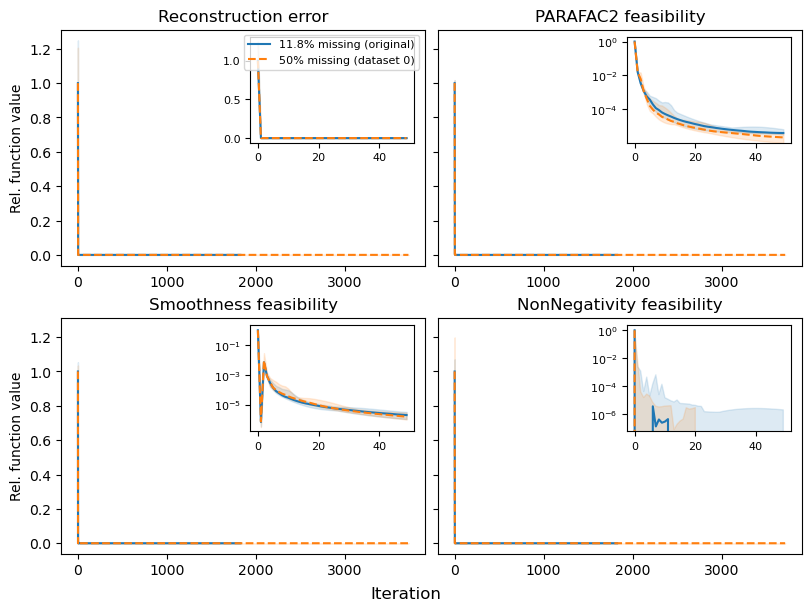

In [ ]:
def plot_convergence_compare(results_dict, zoom_in_to_first_n=50, colors=None, linestyles=None, normalize=True):
    """
    Overlay convergence curves for multiple conditions on the same 4 panels.
    results_dict : {label: list_of_result_dicts}
    feasibility_gaps per iter: [NN_gap, PF2_gap, GL_gap]
    normalize    : if True, divide each curve by med[0] (shared reference).
    """
    if colors is None:
        colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    if linestyles is None:
        linestyles = ["-"] * len(results_dict)

    fig, axs = plt.subplot_mosaic(
        [["rec_errors",           "parafac2_feasibility"],
         ["smoothness_feasibility", "nn_feasibility"]],
         sharey=True,
        figsize=(8, 6), layout="constrained",
    )
    inset_axes = {
        key: axs[key].inset_axes([0.52, 0.52, 0.45, 0.45])
        for key in axs
    }
    for ins in inset_axes.values():
        ins.tick_params(labelsize=8)

    for (label, results), color, ls in zip(results_dict.items(), colors, linestyles):
        runs = [
            r for r in results
            if r["exit"] == "OK"
            and r["feasibility_gaps"] is not None
            and len(r["rec_errors"]) < 8000
            and max(r["feasibility_gaps"][-1]) <= 1e-6
        ]
        if not runs:
            print(f"{label}: no valid runs, skipping.")
            continue

        max_iters = max(r["n_iter"] for r in runs)
        med_rec, min_rec, max_rec = [], [], []
        med_pf2, min_pf2, max_pf2 = [], [], []
        med_smo, min_smo, max_smo = [], [], []
        med_nn,  min_nn,  max_nn  = [], [], []

        for iter_no in range(max_iters):
            cur_rec, cur_pf2, cur_smo, cur_nn = [], [], [], []
            for r in runs:
                if iter_no < r["n_iter"]:
                    cur_rec.append(r["rec_errors"][iter_no])
                    gaps = r["feasibility_gaps"][iter_no]  # [NN_gap, PF2_gap, GL_gap]
                    if len(gaps) >= 1: cur_nn.append(gaps[0])
                    if len(gaps) >= 2: cur_pf2.append(gaps[1])
                    if len(gaps) >= 3: cur_smo.append(gaps[2])
            if cur_rec:
                med_rec.append(np.median(cur_rec)); min_rec.append(min(cur_rec)); max_rec.append(max(cur_rec))
            if cur_pf2:
                med_pf2.append(np.median(cur_pf2)); min_pf2.append(min(cur_pf2)); max_pf2.append(max(cur_pf2))
            if cur_smo:
                med_smo.append(np.median(cur_smo)); min_smo.append(min(cur_smo)); max_smo.append(max(cur_smo))
            if cur_nn:
                med_nn.append(np.median(cur_nn)); min_nn.append(min(cur_nn)); max_nn.append(max(cur_nn))

        def _draw(ax, ins_ax, med, lo, hi, log_scale=False):
            if normalize and med and med[0] != 0:
                ref = med[0]
                med = [v / ref for v in med]
                lo  = [v / ref for v in lo]
                hi  = [v / ref for v in hi]
            x = range(len(med)); z = min(zoom_in_to_first_n, len(med))
            ax.fill_between(x, lo, hi, color=color, alpha=0.15)
            ax.plot(x, med, color=color, linestyle=ls, label=label)
            ins_ax.fill_between(range(z), lo[:z], hi[:z], color=color, alpha=0.15)
            ins_ax.plot(range(z), med[:z], color=color, linestyle=ls)
            if log_scale:
                ins_ax.set_yscale("log")
            all_y = [v for v in list(lo[:z]) + list(med[:z]) + list(hi[:z]) if np.isfinite(v)]
            pos_y = [v for v in all_y if v > 0]
            cur_lo, cur_hi = ins_ax.get_ylim()
            if log_scale and pos_y:
                ins_ax.set_ylim(min(min(pos_y), cur_lo), max(max(pos_y), cur_hi))
            elif not log_scale and all_y:
                ins_ax.set_ylim(min(min(all_y), cur_lo), max(max(all_y), cur_hi))

        _draw(axs["rec_errors"], inset_axes["rec_errors"], med_rec, min_rec, max_rec)
        if med_pf2:
            _draw(axs["parafac2_feasibility"],   inset_axes["parafac2_feasibility"],   med_pf2, min_pf2, max_pf2, log_scale=True)
        if med_smo:
            _draw(axs["smoothness_feasibility"], inset_axes["smoothness_feasibility"], med_smo, min_smo, max_smo, log_scale=True)
        if med_nn:
            _draw(axs["nn_feasibility"],         inset_axes["nn_feasibility"],         med_nn,  min_nn,  max_nn,  log_scale=True)

    ylabel = "Rel. function value" if normalize else "Value"
    fig.supxlabel('Iteration')
    axs["rec_errors"].set_title("Reconstruction error");        axs["rec_errors"].set_ylabel(ylabel)
    axs["parafac2_feasibility"].set_title("PARAFAC2 feasibility")
    axs["smoothness_feasibility"].set_title("Smoothness feasibility"); axs["smoothness_feasibility"].set_ylabel(ylabel)
    axs["nn_feasibility"].set_title("NonNegativity feasibility")
    axs["rec_errors"].legend(fontsize=8)
    plt.show()
    fig.savefig(fp + '/analysis_results/figures/FigS16.png', dpi=300, bbox_inches='tight')



rng_conv  = np.random.default_rng(seed=42)
ds_plot   = int(rng_conv.integers(0, N_DATASETS))
plot_convergence_compare(
    {
        "11.8% missing (original)":                    [r for r in ref_results if r["exit"] == "OK"],
        f"50% missing (dataset {ds_plot})": [r for r in results_robust
                                              if r.get("dataset_idx") == ds_plot
                                              and abs(r.get("missing_rate", 0) - 0.50) < 1e-12
                                              and r["exit"] == "OK"],
    },
    linestyles=["-", "--"],
)


In [11]:
# Diagnostic: inspect raw feasibility_gaps from the first few runs of each condition
for label, pool in {
    "~14% missing": [r for r in ref_results if r["exit"] == "OK"],
    f"50% missing (dataset {ds_plot})": [
        r for r in results_robust
        if r.get("dataset_idx") == ds_plot
        and abs(r.get("missing_rate", 0) - 0.50) < 1e-12
        and r["exit"] == "OK"
    ],
}.items():
    runs = [
        r for r in pool
        if r["feasibility_gaps"] is not None
        and len(r["rec_errors"]) < 8000
        and max(r["feasibility_gaps"][-1]) <= 1e-6
    ]
    print(f"\n=== {label}: {len(runs)} valid runs ===")
    for run_i, r in enumerate(runs[:3]):
        print(f"\n  Run {run_i} (init_no={r['init_no']}):")
        print(f"    n_iter={r['n_iter']}  len(feasibility_gaps)={len(r['feasibility_gaps'])}")
        print(f"    feasibility_gaps[0]  = {r['feasibility_gaps'][0]}")
        print(f"    feasibility_gaps[1]  = {r['feasibility_gaps'][1]}")
        print(f"    feasibility_gaps[2]  = {r['feasibility_gaps'][2]}")
        print(f"    feasibility_gaps[-1] = {r['feasibility_gaps'][-1]}")
        # How many iterations have a zero first gap?
        n_zero = sum(1 for g in r['feasibility_gaps'] if len(g) >= 1 and g[0] == 0.0)
        print(f"    iters with gaps[0]==0.0: {n_zero}/{len(r['feasibility_gaps'])}")
        # First non-zero
        for it, g in enumerate(r['feasibility_gaps']):
            if len(g) >= 1 and g[0] != 0.0:
                print(f"    First non-zero gaps[0] at iter {it}: {g[0]:.3e}")
                break



=== ~14% missing: 20 valid runs ===

  Run 0 (init_no=719549):
    n_iter=1617  len(feasibility_gaps)=1618
    feasibility_gaps[0]  = [np.float64(0.6819991903231739), np.float64(0.9638178357007512), np.float64(0.7438295045341027)]
    feasibility_gaps[1]  = [np.float64(0.0), np.float64(0.016015004309330592), np.float64(5.618544383210632e-07)]
    feasibility_gaps[2]  = [np.float64(0.0), np.float64(0.003431737875754289), np.float64(0.005680438381372116)]
    feasibility_gaps[-1] = [np.float64(0.0), np.float64(1.002474750485877e-07), np.float64(6.9034489758890565e-09)]
    iters with gaps[0]==0.0: 1611/1618
    First non-zero gaps[0] at iter 0: 6.820e-01

  Run 1 (init_no=326972):
    n_iter=1624  len(feasibility_gaps)=1625
    feasibility_gaps[0]  = [np.float64(0.7187158928417227), np.float64(0.9398240931161915), np.float64(0.7205943018698049)]
    feasibility_gaps[1]  = [np.float64(0.0), np.float64(0.01455119215909428), np.float64(5.044094105094663e-07)]
    feasibility_gaps[2]  = [np

Valid runs final rec errors: [0.22103283 0.22103128 0.22102237 0.22103125 0.22103807 0.22102243
 0.22103935 0.22102472 0.22102312 0.22100524 0.22103322 0.22101364
 0.22102989 0.22102466 0.22103033 0.22102002 0.22104562 0.22102642
 0.22103947 0.22102398]
Valid runs final rec errors: [0.1895052  0.18948844 0.18948567 0.18950526 0.1894982  0.18948977
 0.18950511 0.18948845 0.18950252 0.18949284 0.18950362 0.18947865
 0.1895038  0.18948246 0.18949236 0.1894957  0.1894921  0.18948592
 0.18950542 0.18952194]
Valid runs final rec errors: [0.16220306 0.16218135 0.1621825  0.16219995 0.16217971 0.16218581
 0.1621919  0.16218213 0.16220064 0.16218851 0.16220243 0.16217087
 0.16219385 0.16219092 0.16219805 0.16218387 0.16219469 0.16219891
 0.16220367 0.16218908]
Valid runs final rec errors: [0.13377365 0.13376722 0.13376704 0.13378129 0.13376128 0.13379395
 0.13379495 0.13377158 0.13377795 0.13379192 0.13379079 0.13375858
 0.13379148 0.13376703 0.13378619 0.13377154 0.13378715 0.13379455
 0.13379

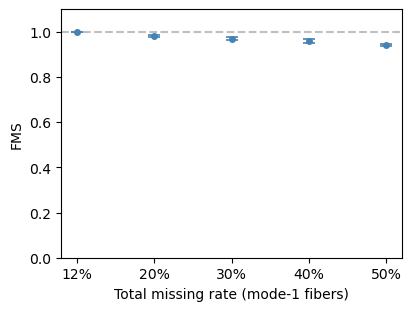

In [ ]:
# FMS between reference model and each extra-masked model, with error bars across datasets
sB_ref = np.array([C_ref[k] * B_ref[k] for k in range(K_f)])
ref_cp = CPTensor((np.ones(RANK), (A_ref, np.vstack(sB_ref))))

# Collect one FMS value per (dataset, rate)
fms_by_rate = {rate: [] for rate in target_rates_farmm}

for ds_idx in sorted(extra_masks_farmm.keys()):
    for rate in target_rates_farmm:
        runs = [
            r for r in results_robust
            if r.get("dataset_idx") == ds_idx
            and abs(r.get("missing_rate", np.nan) - rate) < 1e-12
        ]
        best, log = select_best(runs)
        if best is None:
            print(f"dataset={ds_idx}, rate={rate:.0%}: no valid run. log={log}")
            fms_by_rate[rate].append(np.nan)
            continue
        C_rec, B_rec, A_rec = best["factors"]
        sB_rec = np.array([C_rec[k] * B_rec[k] for k in range(K_f)])
        rec_cp = CPTensor((np.ones(RANK), (A_rec, np.vstack(sB_rec))))
        fms = factor_match_score(ref_cp, rec_cp, absolute_value=True, consider_weights=False)
        fms_by_rate[rate].append(fms)

# Print summary table
print(f"{'Rate':>6}  {'Mean FMS':>10}  {'Std':>8}  {'N valid':>8}")
for rate in target_rates_farmm:
    vals = [v for v in fms_by_rate[rate] if not np.isnan(v)]
    print(f"{rate:.0%}      {np.mean(vals):10.4f}  {np.std(vals):8.4f}  {len(vals):8d}")

# Plot mean ± std; reference point at existing_rate with FMS=1
plot_rates = [existing_rate] + target_rates_farmm
fms_means  = [1.0] + [np.nanmean(fms_by_rate[r]) for r in target_rates_farmm]
fms_stds   = [0.0] + [np.nanstd(fms_by_rate[r])  for r in target_rates_farmm]
x          = list(range(len(plot_rates)))
x_labels   = [f"{r:.0%}" for r in plot_rates]

fig, ax = plt.subplots(figsize=(4, 3), constrained_layout=True)
ax.errorbar(x, fms_means, yerr=fms_stds, marker='o', markersize=4, linestyle='none', color='steelblue',
            capsize=4, capthick=1.2, elinewidth=1.2, label='mean ± std')
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_xlabel('Total missing rate (mode-1 fibers)')
ax.set_ylabel('FMS')
# ax.set_title('Factor recovery with additional missing data')
ax.set_ylim(0, 1.1)
fig.savefig(fp + '/analysis_results/figures/FigS15.png', dpi=300, bbox_inches='tight')
plt.show()
